# Mise en situation 

Imaginons qu'on est embauché en tant que data scientist junior dans une entreprise.
Notre manager nous accueille et nous explique :
"Nous perdons des clients chaque mois et nous ne savons pas pourquoi. Nous avons
aussi du mal à prédire combien chaque client va dépenser."
J'ai besoin de vous pour deux missions :
1. Régression : Prédire la **dépense annuelle** de chaque client (en euros).
2. Classification : Prédire si un client va **partir** (churn = 1) ou **rester** (churn = 0).

# Importation des bibliothèques 

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

# Création des datasets

In [3]:
data = {
 'Client_ID': list ( range (1 , 21) ) ,
 'Age': [25 , 34 , 28 , 45 , 23 , 52 , 31 , 41 , 27 , 38 , 55 , 29 , 47 , 22 , 36 , 43 , 26 , 50 , 33 , 30] ,
 'Revenu': [22 , 45 , 28 , 62 , 18 , 75 , 35 , 55 , 24 , 48 , 80 , 30 , 65 , 20 , 42 , 58 , 25 , 70 , 38 , 32] ,
 'Anciennete': [1 , 5, 2, 8, 1 , 12 , 3, 7, 1, 6 , 15 , 2, 9, 1 , 4, 7, 1 , 10 , 3 , 2] ,
 'Nb_Achats': [8 , 30 , 12 , 55 , 5, 70 , 18 , 45 , 7, 35 , 85 , 14 , 60 , 6, 25 , 48 , 9, 65 , 20 , 15] ,
 'Montant_Moyen': [45 , 78 , 52 , 95 , 38 , 110 , 62 , 88 , 42 , 82 , 120 , 55 , 98 , 40 , 72 , 90 , 48 , 105 , 65 , 58] ,
 'Depense_Annuelle': [360 , 2340 , 624 , 5225 , 190 , 7700 , 1116 , 3960 , 294 , 2870 , 10200 , 770 , 5880 , 240 , 1800 , 4320 , 432 , 6825 , 1300 , 870] ,
 'Score_Satisfaction': [5 , 8, 4 , 9, 3, 9, 6 , 8, 4, 7, 10 , 5, 9, 3 , 7, 8, 4 , 9 , 6, 5] ,
 'Churn': [1 , 0 , 1 , 0, 1, 0 , 0 , 0, 1, 0 , 0, 1, 0 , 1 , 0, 0, 1 , 0 , 0, 1]
}

df = pd.DataFrame(data)
print("===== Notre datasets =====")
print(df)
print(f"\nDimension : {df.shape[0]} ligne x {df.shape[1]} colonnes")

===== Notre datasets =====
    Client_ID  Age  Revenu  Anciennete  Nb_Achats  Montant_Moyen  \
0           1   25      22           1          8             45   
1           2   34      45           5         30             78   
2           3   28      28           2         12             52   
3           4   45      62           8         55             95   
4           5   23      18           1          5             38   
5           6   52      75          12         70            110   
6           7   31      35           3         18             62   
7           8   41      55           7         45             88   
8           9   27      24           1          7             42   
9          10   38      48           6         35             82   
10         11   55      80          15         85            120   
11         12   29      30           2         14             55   
12         13   47      65           9         60             98   
13         14   22   

In [4]:
# Exploration des données 
print("===== 5 premiers lignes de notre datasets =====")
print(df.head())
print("\n ===== Information des variables =====")
print(df.info())
print("\n ===== Statistiques descriptive =====")
print(df.describe().round(2))

===== 5 premiers lignes de notre datasets =====
   Client_ID  Age  Revenu  Anciennete  Nb_Achats  Montant_Moyen  \
0          1   25      22           1          8             45   
1          2   34      45           5         30             78   
2          3   28      28           2         12             52   
3          4   45      62           8         55             95   
4          5   23      18           1          5             38   

   Depense_Annuelle  Score_Satisfaction  Churn  
0               360                   5      1  
1              2340                   8      0  
2               624                   4      1  
3              5225                   9      0  
4               190                   3      1  

 ===== Information des variables =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Client_ID     

In [5]:
print("===== Statistiques par groupes =====")
print(df.groupby('Churn').mean().round(2))

print("\n===== Nombre de clients par groupe =====")
print(df['Churn'].value_counts())
print(f"\n Porcentage de Churn : {df['Churn'].mean()*100:.1f}%")

===== Statistiques par groupes =====
       Client_ID    Age  Revenu  Anciennete  Nb_Achats  Montant_Moyen  \
Churn                                                                   
0          10.75  42.08   56.08        7.42      46.33          88.75   
1          10.12  26.25   24.88        1.38       9.50          47.25   

       Depense_Annuelle  Score_Satisfaction  
Churn                                        
0               4461.33                8.00  
1                472.50                4.12  

===== Nombre de clients par groupe =====
Churn
0    12
1     8
Name: count, dtype: int64

 Porcentage de Churn : 40.0%


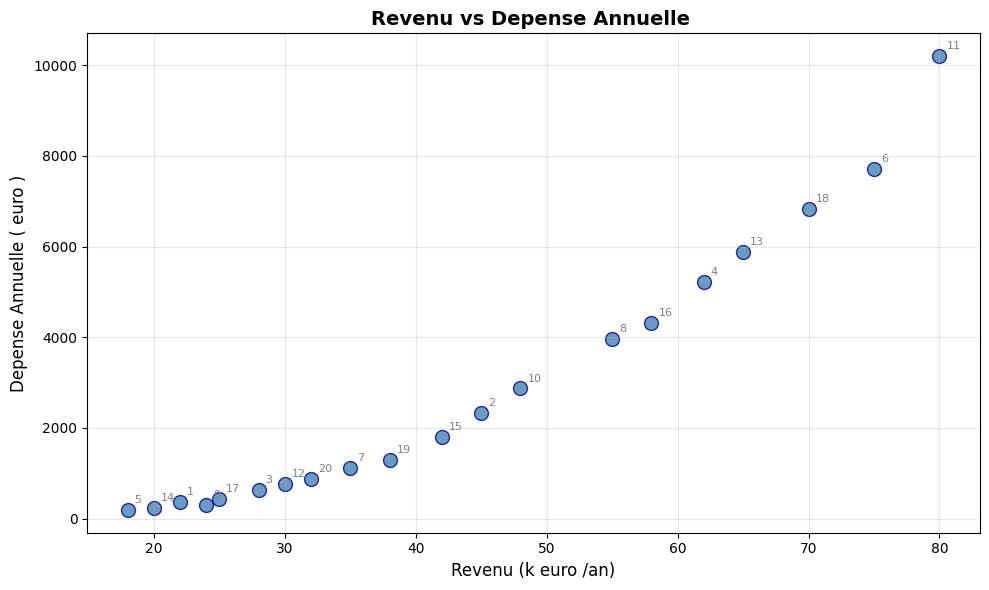

In [6]:
# Ici je veux comparer graphiquement le revenu et la depense annuelle
plt.figure(figsize=(10 , 6))
plt.scatter( df['Revenu'], df['Depense_Annuelle'], c='steelblue', s =100 , edgecolors ='navy', alpha =0.8)
plt.xlabel ('Revenu (k euro /an)', fontsize =12)
plt.ylabel ('Depense Annuelle ( euro )', fontsize =12)
plt.title ('Revenu vs Depense Annuelle ', fontsize =14 , fontweight ='bold')
plt.grid (True , alpha =0.3)

# Ajouter les numeros des clients
for i , row in df.iterrows () :
    plt.annotate (str( row ['Client_ID']) , ( row ['Revenu'] , row ['Depense_Annuelle']) , textcoords ="offset points", xytext =(5 , 5) , fontsize =8 , color ='gray')
plt.tight_layout ()
plt.show ()  

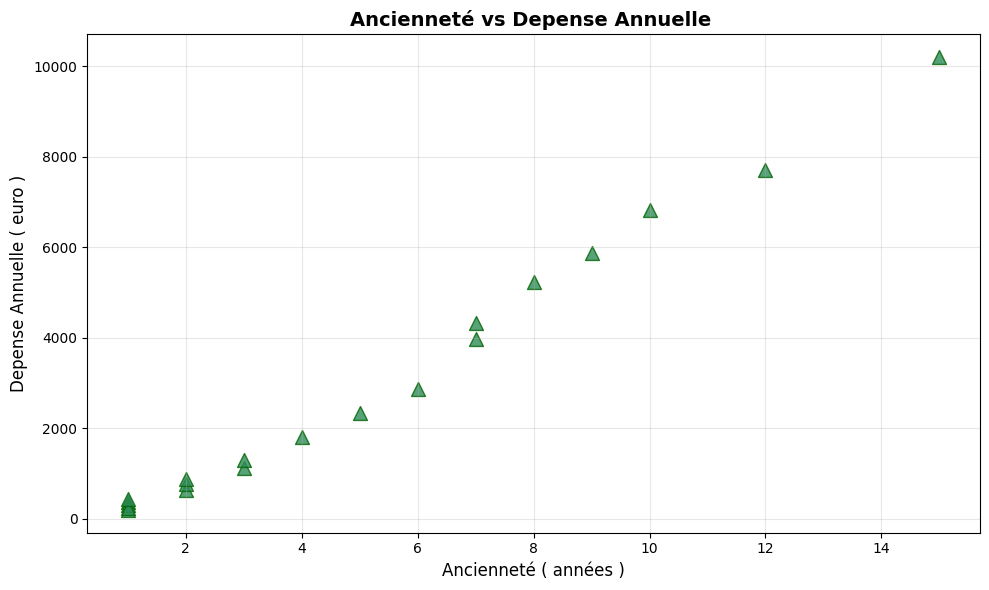

In [7]:
# Ici je compare graphiquement l'ancinneté et leur depense annuelle 
plt.figure( figsize =(10 , 6) )
plt.scatter( df['Anciennete'], df['Depense_Annuelle'] , c='seagreen', s =100 , edgecolors ='darkgreen',marker ='^', alpha =0.8)
plt.xlabel ('Ancienneté ( années )', fontsize =12)
plt.ylabel ('Depense Annuelle ( euro )', fontsize =12)
plt.title ('Ancienneté vs Depense Annuelle ', fontsize =14 , fontweight ='bold')
plt.grid (True , alpha =0.3)
plt.tight_layout ()
plt.show ()

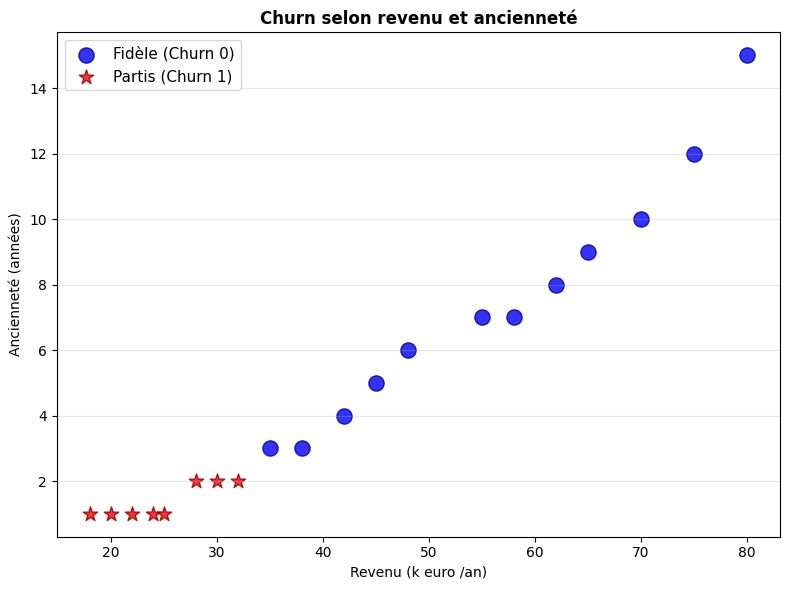

In [11]:
# Classification des churn par revenu et ancienneté 
plt.figure(figsize=(8,6))

fidele = df[df['Churn'] == 0]
partis = df[df['Churn'] == 1]

plt.scatter(fidele['Revenu'], fidele['Anciennete'], color='blue', s=120, marker='o', label='Fidèle (Churn 0)', edgecolor='navy', alpha=0.8)
plt.scatter(partis['Revenu'], partis['Anciennete'], color='red', s=120, marker='*', label='Partis (Churn 1)', edgecolor='darkred', alpha=0.8)

plt.xlabel("Revenu (k euro /an)", fontsize=10)
plt.ylabel("Ancienneté (années)", fontsize=10)
plt.title("Churn selon revenu et ancienneté", fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

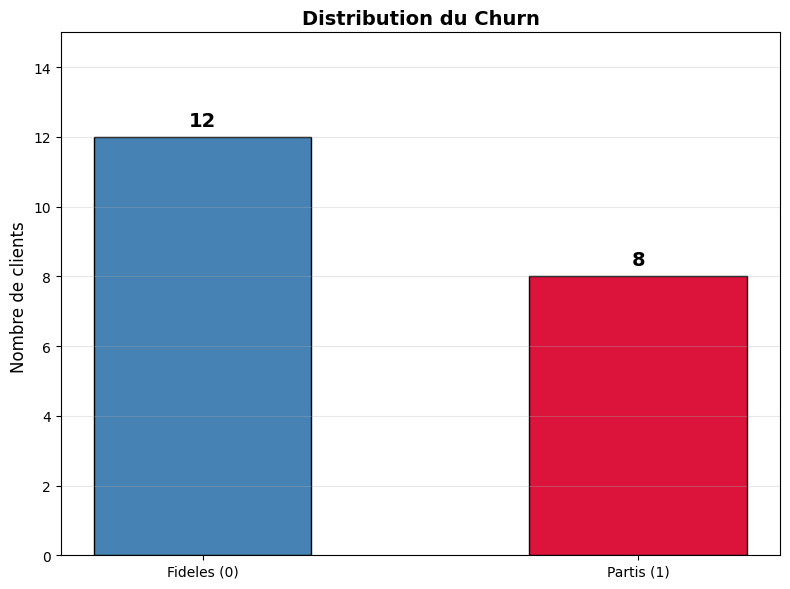

In [14]:
# Distribution du Churn
plt.figure(figsize=(8,6))
churn_counts = df['Churn'].value_counts()
colors = ['steelblue', 'crimson']
bars = plt.bar([ 'Fideles (0)', 'Partis (1)'], [ churn_counts[0] , churn_counts[1]] , color = colors , edgecolor ='black', width =0.5)

# Ajouter les valeurs sur les barres
for bar in bars :
    height = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2. , height + 0.2 ,f'{int( height)}', ha ='center', va ='bottom', fontsize =14 , fontweight ='bold')

plt.ylabel ('Nombre de clients ', fontsize =12)
plt.title ('Distribution du Churn', fontsize =14 , fontweight ='bold')
plt.ylim (0 , 15)
plt.grid ( axis ='y', alpha =0.3)
plt.tight_layout ()

# Matrice de corrélation 

 === Matrice de correlation === 
                     Age  Revenu  Anciennete  Nb_Achats  Montant_Moyen  \
Age                 1.00    1.00        0.98       0.99           0.99   
Revenu              1.00    1.00        0.98       0.99           1.00   
Anciennete          0.98    0.98        1.00       0.99           0.98   
Nb_Achats           0.99    0.99        0.99       1.00           0.98   
Montant_Moyen       0.99    1.00        0.98       0.98           1.00   
Depense_Annuelle    0.97    0.97        0.99       0.99           0.96   
Score_Satisfaction  0.95    0.96        0.92       0.94           0.97   
Churn              -0.79   -0.80       -0.74      -0.75          -0.82   

                    Depense_Annuelle  Score_Satisfaction  Churn  
Age                             0.97                0.95  -0.79  
Revenu                          0.97                0.96  -0.80  
Anciennete                      0.99                0.92  -0.74  
Nb_Achats                       0.99

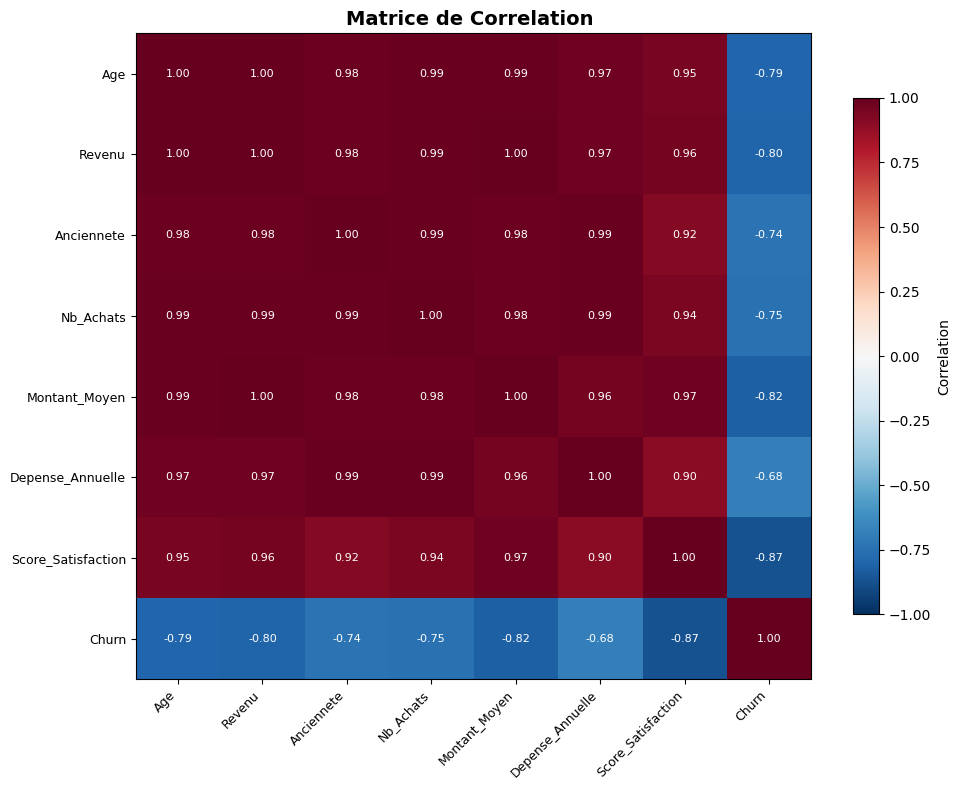

In [19]:
cols = ['Age', 'Revenu', 'Anciennete', 'Nb_Achats','Montant_Moyen', 'Depense_Annuelle','Score_Satisfaction', 'Churn']
corr_matrix = df[cols].corr().round (2)
print (" === Matrice de correlation === ")
print (corr_matrix)
# Heatmap de la correlation
plt.figure( figsize =(10 , 8) )
im = plt.imshow(corr_matrix.values , cmap ='RdBu_r', vmin = -1 , vmax =1 , aspect ='auto')
plt.colorbar(im , shrink =0.8 , label ='Correlation')

# Ajouter les labels
plt.xticks(range(len(cols)) , cols , rotation =45 , ha ='right',fontsize =9)
plt.yticks (range(len(cols)) , cols , fontsize =9)

# Ajouter les valeurs dans les cellules
for i in range (len( cols )):
    for j in range (len( cols )):
        val = corr_matrix . values [i , j ]
        color = 'white' if abs( val ) > 0.6 else 'black'
        plt.text(j , i , f'{val :.2f}', ha ='center', va ='center',fontsize =8 , color = color )
plt.title ('Matrice de Correlation ', fontsize =14 , fontweight ='bold')
plt.tight_layout ()